# MCS Track Statistics by COF Type — Multi-Source Comparison

Diagnostic notebook comparing **MCS lifetime statistics** across six model/observation
datasets (OBS, SCREAM, ICON, UM, NICAM, CASESM2), stratified by the
**Co-occurring Feature (COF) type** of each MCS track.

---

## Input data

Input is a single snappy-compressed parquet file generated by
**`scripts/combine_mcs_cof_trackstats_multisource.py`** from the per-source COF files of **`scripts/extract_mcs_cof_tracks.py`**
(which scans the COF mask store of Step 3 along each MCS track), which:

1. Loads PyFLEXTRKR MCS track-statistics netCDF files and the per-source COF 2-D overlap files (tracks × times)
   for all six sources.
2. Filters out tracks that are not extra-tropical (retains tracks with
   lifetime-median |meanlat| ≥ 20°).
3. Converts to a tidy per-time-step DataFrame and writes a single parquet file.

| Dataset  | Description |
|----------|-------------|
| OBS      | GPM/IMERG-based observations |
| SCREAM   | SCREAMv1-cess2 GSRM simulation |
| ICON     | ICON GSRM simulation |
| UM       | UM GSRM simulation |
| NICAM    | NICAM GSRM simulation |
| CASESM2  | CAM-SE CAM6 GSRM simulation |

**Parquet file** (CFS copy, identical to the production file in `/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/`):
`/global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/mcs_cof_trackstats_allsources.parquet`  
~267 MB · ~1.95 M rows · 77 columns (regenerated on 2026-09-21 from the COF flags of the round-2 Step 3 stores)

---

## Key analysis steps

1. **Load & preprocess** — read parquet, convert epoch timestamps to datetime,
   derive `ccs_area_all`, `core_area_ratio`, `heavy_rain_ratio`, and `total_rainvol` (m³).
2. **COF overlap fractions** — for each track compute the fraction of time steps
   co-occurring with AR only (`frac_ar`), ETC only (`frac_etc`), and both
   AR-ETC (`frac_ar_etc`).
3. **COF-type classification** — assign each track to one of four mutually
   exclusive types based on the dominant overlap fraction:

   | COF type | Rule |
   |----------|------|
   | Isolated   | all fractions == 0 |
   | MCS-AR-ETC | `frac_ar_etc` ≥ both 2-way fractions (3-way prioritised on ties) |
   | MCS-AR     | not 3-way, and `frac_ar > frac_etc` |
   | MCS-ETC    | not 3-way, and `frac_ar ≤ frac_etc` (a tie of the two 2-way fractions goes to MCS-ETC) |

4. **Lifetime aggregation** — reduce the per-time-step DataFrame to one row
   per track (`df_lt`) using physically appropriate aggregations (max, min,
   sum, median, mean) for each variable.
5. **Ocean / land sub-populations** — subset `df_lt` into ocean MCS
   (`pf_landfrac_lt_max < 0.05`) and land MCS (`pf_landfrac_lt_mean > 0.80`).

---

## Analysis plots

| Figure | Description |
|--------|-------------|
| **Box plots — All MCS** | 3 × 3 panel box plots of nine MCS lifetime statistics (track duration, max CCS area, minimum 11-µm Tb, movement speed, max PF major-axis length, max PF aspect ratio, max PF rain rate, total rain volume, and heavy-rain fraction) grouped by COF type and coloured by dataset. |
| **Box plots — Ocean MCS** | Same 3 × 3 layout restricted to ocean MCS tracks (`pf_landfrac_lt_max < 0.05`). |
| **Box plots — Land MCS** | Same 3 × 3 layout restricted to land MCS tracks (`pf_landfrac_lt_mean > 0.80`). |

The legends of the box plots give the **average number of tracks per year** in the four COF types (in the order of the x-axis): the count divided by the number of years covered by the
dataset's track times (OBS 3.0, SCREAM 1.09, UM 1.08, ICON, NICAM and CASESM2 1.0), so that the 3-year observations and the roughly 1-year models are comparable. Two HTML tables with the
significance tests of the lifetime statistics (`Table_MCS_sig_ocean.html`, `Table_MCS_sig_land.html`) are saved next to the figures.

All figures are saved to:  
`/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs_202609/`


In [8]:
import time
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import colormaps as colormaps
import warnings
warnings.filterwarnings('ignore')

## Data

The combined MCS track statistics + COF 2D overlap data are stored in a single snappy-compressed parquet file generated by **`scripts/combine_mcs_cof_trackstats_multisource.py`**, which:

1. Loads MCS track stats + COF 2D netCDF files for all 6 sources (OBS, SCREAM, ICON, UM, NICAM, CASESM2)
2. Filters out tropical tracks (lifetime-median |meanlat| < 20°, retaining extra-tropical MCS only)
3. Converts to a tidy per-time-step DataFrame and saves as parquet

**Output:** `/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/mcs_cof_trackstats_allsources.parquet`
~200 MB · ~1.48 M rows · 74 columns · ~8 min to generate for all 6 sources

In [9]:
# Paths
# cof_dir      = "/pscratch/sd/w/wcmca1/hackathon/cof_masks/stats/"
cof_dir      = "/global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/"
parquet_path = os.path.join(cof_dir, "mcs_cof_trackstats_allsources.parquet")
fig_dir      = "/global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs_202609/"
os.makedirs(fig_dir, exist_ok=True)

# Color scheme for sources (keyed by display name matching the 'dataset' column)
source_colors = {
    'OBS':     'darkgray',
    'SCREAM':  'dodgerblue',
    'ICON':    'deeppink',
    'UM':      'lime',
    'NICAM':   'green',
    'CASESM2': 'darkorange',
}

# Load the combined parquet file
print(f"Loading: {parquet_path}")
t0 = time.time()
df_all_src = pd.read_parquet(parquet_path)
print(f"Loaded in {time.time() - t0:.1f} s  |  "
      f"{df_all_src.shape[0]:,} rows × {df_all_src.shape[1]} cols")
print(f"Sources: {sorted(df_all_src['dataset'].unique().tolist())}")

Loading: /global/cfs/cdirs/wcm_shr/hk25/cof_masks/stats/mcs_cof_trackstats_allsources.parquet
Loaded in 2.1 s  |  1,951,841 rows × 77 cols
Sources: ['CASESM2', 'ICON', 'NICAM', 'OBS', 'SCREAM', 'UM']


In [10]:
# Convert epoch-second columns to pandas datetime (UTC, then timezone-stripped)
# base_time    : datetime of each valid time step
# start_basetime : track initiation time
# end_basetime   : track termination time
for col in ['base_time', 'start_basetime', 'end_basetime']:
    if col in df_all_src.columns:
        df_all_src[f'{col}_dt'] = pd.to_datetime(
            df_all_src[col], unit='s', origin='unix', utc=True
        ).dt.tz_localize(None)   # drop UTC tz-awareness → naive datetime

print("Added datetime columns:")
for col in ['base_time_dt', 'start_basetime_dt', 'end_basetime_dt']:
    if col in df_all_src.columns:
        print(f"  {col}: {df_all_src[col].dtype}  "
              f"range [{df_all_src[col].min()} → {df_all_src[col].max()}]")

Added datetime columns:
  base_time_dt: datetime64[ns]  range [2019-01-01 00:00:00 → 2021-12-31 23:00:00]
  start_basetime_dt: datetime64[ns]  range [2019-01-01 00:00:00 → 2021-12-31 18:00:00]
  end_basetime_dt: datetime64[ns]  range [2019-01-01 07:00:00 → 2021-12-31 23:00:00]


In [11]:
# ── Average count per year ────────────────────────────────────────────────────
# Sample sizes (numbers of tracks) in legends, titles and labels are shown as an AVERAGE NUMBER PER YEAR, so that a 3-year observational record and
# 1-year model records are comparable. The number of years comes from the time stamps of the data, not from counting calendar years.
def estimate_n_years(times):
    """
    Number of years covered by a set of time stamps: (last - first time stamp) / 365.25 days.

    A record that crosses a calendar year (e.g. Aug 2019 - Aug 2020) counts as one year, not two, and a record with gaps still counts its whole span.
    Fractions are kept (a 13-month record is 1.09 years). Invalid (NaT) time stamps are ignored.
    """
    t = pd.Series(pd.to_datetime(np.asarray(times).ravel())).dropna()
    if t.empty or t.max() == t.min():
        raise ValueError("the number of years needs at least two different valid time stamps")
    return (t.max() - t.min()) / pd.Timedelta(days=365.25)


def format_per_year(count, n_years=None):
    """Format a track count for a legend or label: count / n_years (an average per year), or the plain count when n_years is None."""
    if n_years is None:
        return f"{int(round(count)):,}"
    value = float(count) / float(n_years)
    if value == 0:
        return "0"
    return f"{value:,.0f}" if round(value, 1) >= 10 else f"{value:.1f}"


# ── Years covered by each source (from the time stamps of the track steps, base_time_dt) ──
n_years_by_dataset = {}
for _name, _grp in df_all_src.groupby('dataset'):
    n_years_by_dataset[_name] = estimate_n_years(_grp['base_time_dt'])
print("Years of data per dataset:")
for _name, _yrs in n_years_by_dataset.items():
    print(f"  {_name:<8} {_yrs:5.2f} years")


Years of data per dataset:
  CASESM2   1.00 years
  ICON      1.00 years
  NICAM     1.00 years
  OBS       3.00 years
  SCREAM    1.09 years
  UM        1.08 years


In [12]:
# Derived variables
# ccs_area_all    : total CCS area including merged and split cloud systems
# core_area_ratio : convective core fraction of the total CCS area
# heavy_rain_ratio: fraction of total rainfall that is heavy rain
# total_rainvol   : rain volume (m³), assuming a uniform 100 km² pixel area
pixel_area = 100  # km² per pixel
df_all_src['ccs_area_all']     = df_all_src['ccs_area'] + df_all_src['merge_ccs_area'] + df_all_src['split_ccs_area']
df_all_src['core_area_ratio']  = df_all_src['core_area'] / df_all_src['ccs_area']
df_all_src['heavy_rain_ratio'] = df_all_src['total_heavyrain'] / df_all_src['total_rain']
df_all_src['total_rainvol']    = df_all_src['total_rain'] * pixel_area * 1e3  # mm × km² → m³

# Replace inf (division by zero when denominator == 0) with NaN
df_all_src.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Derived columns added:")
for col in ['ccs_area_all', 'core_area_ratio', 'heavy_rain_ratio', 'total_rainvol']:
    print(f"  {col}: min={df_all_src[col].min():.4g}, "
          f"max={df_all_src[col].max():.4g}, "
          f"NaN={df_all_src[col].isna().sum():,}")

Derived columns added:
  ccs_area_all: min=900, max=1.281e+07, NaN=0
  core_area_ratio: min=0, max=1, NaN=0
  heavy_rain_ratio: min=0.0002702, max=1, NaN=495,677
  total_rainvol: min=0, max=9.071e+09, NaN=31


In [13]:
# Diagnostic: check valid values in merge_ccs_area and split_ccs_area
for col in ['ccs_area', 'merge_ccs_area', 'split_ccs_area', 'ccs_area_all']:
    s = df_all_src[col]
    n_total  = len(s)
    n_nan    = s.isna().sum()
    n_valid  = n_total - n_nan
    n_nonzero = (s.fillna(0) != 0).sum()
    print(f"{col:25s}  total={n_total:>9,}  NaN={n_nan:>9,}  valid={n_valid:>9,}  nonzero={n_nonzero:>9,}"
          f"  min={s.min():.4g}  max={s.max():.4g}")

print()
print("Per-dataset summary of merge_ccs_area and split_ccs_area:")
for col in ['merge_ccs_area', 'split_ccs_area']:
    print(f"\n  {col}:")
    print(df_all_src.groupby('dataset')[col].agg(['count', 'min', 'max', 'mean',
          lambda x: x.isna().sum()]).rename(columns={'<lambda_0>': 'NaN_count'}).to_string())


ccs_area                   total=1,951,841  NaN=        0  valid=1,951,841  nonzero=1,951,841  min=900  max=8.902e+06
merge_ccs_area             total=1,951,841  NaN=        0  valid=1,951,841  nonzero=  924,994  min=0  max=4.546e+06
split_ccs_area             total=1,951,841  NaN=        0  valid=1,951,841  nonzero=  948,505  min=0  max=4.353e+06
ccs_area_all               total=1,951,841  NaN=        0  valid=1,951,841  nonzero=1,951,841  min=900  max=1.281e+07

Per-dataset summary of merge_ccs_area and split_ccs_area:

  merge_ccs_area:
          count  min        max          mean  NaN_count
dataset                                                 
CASESM2  102304  0.0  2559400.0  12287.218486          0
ICON     297221  0.0  4545600.0  48217.705007          0
NICAM    251787  0.0  2281700.0  18591.117095          0
OBS      733627  0.0  2061000.0  20333.253547          0
SCREAM   373813  0.0  2962300.0  26812.921969          0
UM       193089  0.0  1373800.0  12145.526156          

In [14]:
# Summary table: number of MCS tracks with any COF overlap per source
flag_vars = ['cof_flag_mcs_ar', 'cof_flag_mcs_etc', 'cof_flag_mcs_ar_etc', 'cof_flag_isolated']

rows = []
for src, grp in df_all_src.groupby('dataset'):
    n_tracks = grp['tracks'].nunique()
    row = {'source': src, 'n_tracks': n_tracks}
    for fv in flag_vars:
        if fv in grp.columns:
            # A track has overlap if any time step == 1
            row[fv] = int(grp.groupby('tracks')[fv].max().eq(1).sum())
        else:
            row[fv] = np.nan
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('source')
summary_df.columns = ['N tracks', 'MCS-AR', 'MCS-ETC', 'MCS-AR-ETC', 'Isolated']
print("Number of MCS tracks with any COF overlap:")
summary_df

Number of MCS tracks with any COF overlap:


,N tracks,MCS-AR,MCS-ETC,MCS-AR-ETC,Isolated
source,,,,,
CASESM2,4542,1143,993,850,3224
ICON,13410,2920,2964,2651,11096
NICAM,11744,2578,2621,2273,9461
OBS,35631,7059,8670,7551,28754
SCREAM,20710,3156,5084,3375,17006
UM,9347,1962,1699,1518,7436


In [15]:
# Inspect the combined DataFrame
print("Column list:")
print(df_all_src.columns.tolist())
print()
df_all_src.head(3)


Column list:
['tracks', 'relative_step', 'track_duration', 'start_status', 'end_status', 'start_basetime', 'end_basetime', 'start_split_cloudnumber', 'end_merge_cloudnumber', 'pbc_flag', 'base_time', 'meanlat', 'meanlon', 'area', 'cloudnumber', 'track_status', 'track_interruptions', 'core_area', 'cold_area', 'corecold_mintb', 'corecold_meantb', 'core_meantb', 'lat_mintb', 'lon_mintb', 'meanlon_smooth', 'meanlat_smooth', 'mcs_duration', 'mcs_status', 'ccs_area', 'merge_ccs_area', 'split_ccs_area', 'pf_npf', 'pf_lon', 'pf_lat', 'pf_area', 'pf_rainrate', 'pf_skewness', 'pf_majoraxis', 'pf_minoraxis', 'pf_aspectratio', 'pf_orientation', 'pf_perimeter', 'pf_eccentricity', 'pf_lon_centroid', 'pf_lat_centroid', 'pf_lon_weightedcentroid', 'pf_lat_weightedcentroid', 'pf_lon_maxrainrate', 'pf_lat_maxrainrate', 'pf_maxrainrate', 'pf_accumrain', 'pf_accumrainheavy', 'pf_landfrac', 'total_rain', 'total_heavyrain', 'total_volrain', 'total_heavyvolrain', 'rainrate_heavyrain', 'rainrate_p95', 'pf_life

,tracks,relative_step,track_duration,start_status,end_status,start_basetime,end_basetime,start_split_cloudnumber,end_merge_cloudnumber,pbc_flag,...,relative_time_h,track_duration_h,dataset,base_time_dt,start_basetime_dt,end_basetime_dt,ccs_area_all,core_area_ratio,heavy_rain_ratio,total_rainvol
0,0,0,60,15,3,1.546301e+09,1.546513e+09,-9999,-9999,0,...,0.0,60.0,OBS,2019-01-01 00:00:00,2019-01-01,2019-01-03 11:00:00,1286000.0,0.071984,0.054387,1.720751e+09
1,0,1,60,15,3,1.546301e+09,1.546513e+09,-9999,-9999,0,...,1.0,60.0,OBS,2019-01-01 01:00:00,2019-01-01,2019-01-03 11:00:00,909500.0,0.121609,0.040069,1.786984e+09
2,0,2,60,15,3,1.546301e+09,1.546513e+09,-9999,-9999,0,...,2.0,60.0,OBS,2019-01-01 02:00:00,2019-01-01,2019-01-03 11:00:00,826200.0,0.137181,0.029222,1.759580e+09


In [16]:
# One row per track (deduplicated) — useful for track-level statistics
df_tracks = df_all_src.drop_duplicates(subset=['dataset', 'tracks'])
print("Track duration (h) statistics per source:")
print(
    df_tracks.groupby('dataset')['track_duration_h']
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95])
    .T
)


Track duration (h) statistics per source:
dataset      CASESM2          ICON         NICAM           OBS        SCREAM  \
count    4542.000000  13410.000000  11744.000000  35631.000000  20710.000000   
mean       22.523998     22.164131     21.439629     20.589571     18.049879   
std        25.261159     20.641516     18.089696     15.367601     15.770717   
min         5.000000      5.000000      5.000000      5.000000      5.000000   
25%        12.000000      9.000000     11.000000     11.000000      9.000000   
50%        17.000000     15.000000     16.000000     16.000000     13.000000   
75%        25.000000     27.000000     26.000000     25.000000     21.000000   
90%        39.000000     47.000000     41.000000     39.000000     34.000000   
95%        52.000000     64.000000     55.000000     50.000000     46.000000   
max       375.000000    227.000000    387.000000    239.000000    613.000000   

dataset           UM  
count    9347.000000  
mean       20.657858  
std     

## COF-based MCS track classification

For each track, compute the **fraction of valid time steps** where each COF flag == 1:

| Fraction | COF flag column | Meaning |
|---|---|---|
| `frac_ar` | `cof_flag_mcs_ar` | MCS co-occurs with AR only (2-way) |
| `frac_etc` | `cof_flag_mcs_etc` | MCS co-occurs with ETC only (2-way) |
| `frac_ar_etc` | `cof_flag_mcs_ar_etc` | MCS co-occurs with both AR & ETC (3-way) |

Tracks are then assigned to one of four **COF types** based on the dominant fraction:

1. **Isolated** — all three fractions are 0 (track never overlaps any AR or ETC)
2. **MCS-AR-ETC** — `frac_ar_etc` ≥ both 2-way fractions (3-way prioritised on ties)
3. **MCS-AR** — `frac_ar` is strictly largest
4. **MCS-ETC** — `frac_etc` is strictly largest

In [17]:
# -----------------------------------------------------------------------
# Step 1: compute per-track COF fractions
# cof_flag == 1 means the step overlaps; 0 = no overlap; -1/fill = invalid
# Fraction = (steps with flag==1) / track_duration
# -----------------------------------------------------------------------
def compute_cof_fractions(df):
    """Return a per-track DataFrame with COF overlap fractions."""
    grp = df.groupby(['dataset', 'tracks'], sort=False)
    duration = grp['track_duration'].first()   # same for all steps of a track
    frac = pd.DataFrame({
        'track_duration':  duration,
        'frac_ar':         grp['cof_flag_mcs_ar'].apply(lambda x: (x == 1).sum()) / duration,
        'frac_etc':        grp['cof_flag_mcs_etc'].apply(lambda x: (x == 1).sum()) / duration,
        'frac_ar_etc':     grp['cof_flag_mcs_ar_etc'].apply(lambda x: (x == 1).sum()) / duration,
    })
    return frac.reset_index()

df_cof_frac = compute_cof_fractions(df_all_src)

# -----------------------------------------------------------------------
# Step 2: classify each track into one of 4 COF types
#
# Priority rules (applied in order):
#   1. Isolated    — all three fractions == 0
#   2. MCS-AR-ETC  — frac_ar_etc >= frac_ar  AND  frac_ar_etc >= frac_etc
#                    (3-way wins on ties with either 2-way type)
#   3. MCS-AR      — frac_ar  > frac_etc
#   4. MCS-ETC     — frac_ar <= frac_etc (a tie between frac_ar and frac_etc goes to MCS-ETC)
# -----------------------------------------------------------------------
def classify_cof_type(row):
    fa, fe, fae = row['frac_ar'], row['frac_etc'], row['frac_ar_etc']
    if fa == 0 and fe == 0 and fae == 0:
        return 'Isolated'
    if fae >= fa and fae >= fe:
        return 'MCS-AR-ETC'
    if fa > fe:                            # fa > fae already; fa > fe → AR wins
        return 'MCS-AR'
    return 'MCS-ETC'

df_cof_frac['cof_type'] = df_cof_frac.apply(classify_cof_type, axis=1)

# -----------------------------------------------------------------------
# Step 3: summary table — counts and % per source and type
# -----------------------------------------------------------------------
type_order = ['Isolated', 'MCS-AR-ETC', 'MCS-AR', 'MCS-ETC']

counts = (
    df_cof_frac.groupby(['dataset', 'cof_type'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=type_order, fill_value=0)
)
counts['Total'] = counts.sum(axis=1)

pct = counts[type_order].div(counts['Total'], axis=0).mul(100).round(1)
pct.columns = [f'{c} (%)' for c in type_order]

summary_types = pd.concat([counts, pct], axis=1)
print("MCS track counts and percentage by COF type:")
print(summary_types.to_string())

# -----------------------------------------------------------------------
# Step 4: completeness check — does every track get exactly one type?
# -----------------------------------------------------------------------
n_classified  = len(df_cof_frac)
n_total_tracks = df_all_src.groupby(['dataset', 'tracks']).ngroups
unclassified  = df_cof_frac['cof_type'].isna().sum()

print(f"\nTracks classified : {n_classified:,}")
print(f"Tracks in df      : {n_total_tracks:,}")
print(f"Unclassified      : {unclassified}")
print(f"✓ All tracks accounted for: {n_classified == n_total_tracks and unclassified == 0}")

MCS track counts and percentage by COF type:
         Isolated  MCS-AR-ETC  MCS-AR  MCS-ETC  Total  Isolated (%)  MCS-AR-ETC (%)  MCS-AR (%)  MCS-ETC (%)
dataset                                                                                                     
CASESM2      2160         637     918      827   4542          47.6            14.0        20.2         18.2
ICON         7035        1895    2214     2266  13410          52.5            14.1        16.5         16.9
NICAM        6005        1687    1958     2094  11744          51.1            14.4        16.7         17.8
OBS         17813        5682    5204     6932  35631          50.0            15.9        14.6         19.5
SCREAM      11493        2527    2379     4311  20710          55.5            12.2        11.5         20.8
UM           5257        1123    1565     1402   9347          56.2            12.0        16.7         15.0

Tracks classified : 95,384
Tracks in df      : 95,384
Unclassified      : 0
✓ All 

In [18]:
# Per-track lifetime statistics
# Each variable is aggregated with the operation most physically meaningful for it.
# pf_landfrac appears in both max and median → two output columns.
max_vars    = ['core_area', 'cold_area', 'ccs_area', 'ccs_area_all',
               'pf_area', 'pf_majoraxis', 'pf_aspectratio',
               'pf_maxrainrate', 'pf_rainrate', 'pf_landfrac', 'rainrate_heavyrain']
min_vars    = ['corecold_mintb', 'core_meantb', 'meanlat']
sum_vars    = ['total_rainvol', 'total_heavyrain']
median_vars = ['movement_speed', ]
mean_vars = ['core_area_ratio', 'heavy_rain_ratio', 'pf_landfrac']

df_lt = (
    df_all_src
    .groupby(['dataset', 'tracks'], sort=False)
    .agg(
        **{f'{c}_lt_max':    (c, 'max')    for c in max_vars},
        **{f'{c}_lt_min':    (c, 'min')    for c in min_vars},
        **{f'{c}_lt_sum':    (c, 'sum')    for c in sum_vars},
        **{f'{c}_lt_median': (c, 'median') for c in median_vars},
        **{f'{c}_lt_mean':   (c, 'mean')   for c in mean_vars},
    )
    .reset_index()
)

# Merge in track-level metadata (duration, COF type)
df_lt = df_lt.merge(
    df_all_src[['dataset', 'tracks', 'track_duration_h']].drop_duplicates(),
    on=['dataset', 'tracks'], how='left'
)
df_lt = df_lt.merge(
    df_cof_frac[['dataset', 'tracks', 'cof_type', 'frac_ar', 'frac_etc', 'frac_ar_etc']],
    on=['dataset', 'tracks'], how='left'
)

print(f"df_lt shape: {df_lt.shape}")
print(f"Columns: {df_lt.columns.tolist()}")
df_lt.head(3)

df_lt shape: (95384, 27)
Columns: ['dataset', 'tracks', 'core_area_lt_max', 'cold_area_lt_max', 'ccs_area_lt_max', 'ccs_area_all_lt_max', 'pf_area_lt_max', 'pf_majoraxis_lt_max', 'pf_aspectratio_lt_max', 'pf_maxrainrate_lt_max', 'pf_rainrate_lt_max', 'pf_landfrac_lt_max', 'rainrate_heavyrain_lt_max', 'corecold_mintb_lt_min', 'core_meantb_lt_min', 'meanlat_lt_min', 'total_rainvol_lt_sum', 'total_heavyrain_lt_sum', 'movement_speed_lt_median', 'core_area_ratio_lt_mean', 'heavy_rain_ratio_lt_mean', 'pf_landfrac_lt_mean', 'track_duration_h', 'cof_type', 'frac_ar', 'frac_etc', 'frac_ar_etc']


,dataset,tracks,core_area_lt_max,cold_area_lt_max,ccs_area_lt_max,ccs_area_all_lt_max,pf_area_lt_max,pf_majoraxis_lt_max,pf_aspectratio_lt_max,pf_maxrainrate_lt_max,...,total_heavyrain_lt_sum,movement_speed_lt_median,core_area_ratio_lt_mean,heavy_rain_ratio_lt_mean,pf_landfrac_lt_mean,track_duration_h,cof_type,frac_ar,frac_etc,frac_ar_etc
0,OBS,0,146200.0,1192500.0,1285000.0,1286000.0,375100.0,1276.765869,4.215174,36.614998,...,54435.125000,20.144547,0.064866,0.111023,0.270122,60.0,MCS-AR-ETC,0.000000,0.000000,0.9
1,OBS,1,291500.0,1230400.0,1317900.0,1319500.0,197700.0,859.973267,3.571491,26.334999,...,21616.529297,11.111111,0.114521,0.108716,0.000000,16.0,MCS-AR-ETC,0.000000,0.000000,1.0
2,OBS,2,162100.0,1125400.0,1224700.0,1224700.0,440900.0,2327.899414,8.513833,22.724998,...,19583.074219,18.633900,0.056905,0.109977,0.109009,9.0,MCS-ETC,0.666667,0.666667,0.0


## MCS Track-Type Box Plots

Multi-panel box plots of lifetime statistics from `df_lt`, grouped by COF type on the x-axis with one box per dataset per type.

In [19]:
def plot_boxplots_by_mcs_type(
    df,
    variables,
    var_labels,
    figsize=(18, 10),
    title=None,
    title_y=0.98,
    source_colors=None,
    mcs_type_order=None,
    dataset_order=None,
    showfliers=False,
    whis=(5, 95),
    box_width=0.8,
    xtick_rotation=30,
    notch=False,
    panel_titles=None,
    panel_ylabels=None,
    yscale=None,
    fontsize=12,
    legend_ncol=None,
    legend_y=1.0,
    hspace=0.35,
    wspace=0.3,
    n_years=None,
    figname=None,
):
    """
    Multi-panel box-whisker plots of MCS lifetime statistics by COF type.

    Parameters
    ----------
    df : pd.DataFrame
        Per-track DataFrame (e.g. df_lt) with columns 'cof_type' and 'dataset'.
    variables : list of list of str
        2-D list of column names, e.g. [[var1, var2, var3], [var4, var5, var6]].
        Rows → subplot rows, columns → subplot columns.
    var_labels : dict
        {column_name: y-axis label string}
    figsize : tuple
    title : str or None
        Overall figure suptitle.  None = no suptitle.
    title_y : float
        Vertical position of the suptitle in figure coordinates (0–1).
        Raise above 1.0 to sit above the legend.
    source_colors : dict
        {dataset_display_name: color}.
    mcs_type_order : list of str
        Order of COF types on the x-axis.
    dataset_order : list of str
        Hue order (dataset display names).
    showfliers : bool
    whis : tuple
        (lower_pct, upper_pct) for whiskers.
    box_width : float
    xtick_rotation : int
    notch : bool
    panel_titles : list of list of str or None
    panel_ylabels : list of list of str or None
    yscale : list of list of str or None
        Same shape as variables.  Each entry is a matplotlib scale string
        ('linear', 'log', 'symlog', etc.).  None = all 'linear'.
    fontsize : int or float
        Base font size.  Scales:
          tick labels / axis labels: fontsize
          panel titles: fontsize + 1
          legend: fontsize
          suptitle: fontsize * 1.2
    legend_ncol : int or None
        Number of columns in the legend.  None = one column per dataset.
    legend_y : float
        **Primary control for legend vertical position** in figure coordinates.
        1.0 = flush with the top of the axes area; lower values (e.g. 0.97)
        tuck the legend closer to the top row of panels.  Values > 1.0 push
        it further above.  Adjust this first when the gap looks too large.
    hspace, wspace : float
    n_years : dict or None
        {dataset display name: number of years covered}. When given, the legend shows the average number of tracks per year (count / years)
        instead of the total count, with a legend title that says so. None keeps the total counts.
    figname : str or None
        If not None, save the figure to this path.

    Returns
    -------
    matplotlib.figure.Figure
    """
    if source_colors is None:
        source_colors = {
            'OBS':     'darkgray',
            'SCREAM':  'dodgerblue',
            'ICON':    'deeppink',
            'UM':      'lime',
            'NICAM':   'green',
            'CASESM2': 'darkorange',
        }

    if mcs_type_order is None:
        mcs_type_order = ['Isolated', 'MCS-AR', 'MCS-ETC', 'MCS-AR-ETC']

    if dataset_order is None:
        dataset_order = ['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2']
    dataset_order = [d for d in dataset_order if d in df['dataset'].unique()]

    # Per-dataset, per-COF-type track counts (for legend labels)
    _type_counts = (
        df.groupby(['dataset', 'cof_type'])
        .size()
        .unstack(fill_value=0)
    )

    if legend_ncol is None:
        legend_ncol = len(dataset_order)

    nrows = len(variables)
    ncols = max(len(row) for row in variables)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             gridspec_kw=dict(hspace=hspace, wspace=wspace),
                             squeeze=False)

    meanpointprops = dict(marker='o', markeredgecolor='black', markeredgewidth=1,
                          markerfacecolor='white', markersize=6, zorder=3)
    medianprops = dict(color='k', linewidth=2, zorder=3)

    legend_ax = None  # will hold the axis used to harvest legend handles

    for i, var_row in enumerate(variables):
        for j in range(ncols):
            ax = axes[i, j]

            if j >= len(var_row):
                ax.set_visible(False)
                continue

            var = var_row[j]

            if var not in df.columns:
                ax.text(0.5, 0.5, f'"{var}"\nnot found',
                        ha='center', va='center', fontsize=fontsize, color='red',
                        transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            plot_df = df.dropna(subset=[var])

            sns.boxplot(
                data=plot_df,
                x='cof_type',
                y=var,
                hue='dataset',
                order=mcs_type_order,
                hue_order=dataset_order,
                palette=source_colors,
                showfliers=showfliers,
                whis=list(whis),
                width=box_width,
                showmeans=True,
                meanprops=meanpointprops,
                medianprops=medianprops,
                notch=notch,
                ax=ax,
            )

            # Keep one axis handle for harvesting legend artists
            if legend_ax is None:
                legend_ax = ax

            # Y-axis scale
            scale = 'linear'
            if yscale is not None and i < len(yscale) and j < len(yscale[i]):
                scale = yscale[i][j]
            ax.set_yscale(scale)

            # Y-axis label
            if panel_ylabels is not None and i < len(panel_ylabels) and j < len(panel_ylabels[i]):
                ylabel = panel_ylabels[i][j]
            else:
                ylabel = var_labels.get(var, var)
            ax.set_ylabel(ylabel, fontsize=fontsize, fontweight='bold')
            ax.set_xlabel('')

            # Panel title
            if panel_titles is not None and i < len(panel_titles) and j < len(panel_titles[i]):
                ax.set_title(panel_titles[i][j], fontsize=fontsize + 1,
                             fontweight='bold', loc='left')

            ax.grid(True, alpha=0.8, ls=':', axis='y')
            ax.tick_params(axis='both', labelsize=fontsize)
            ax.tick_params(axis='x', rotation=xtick_rotation)
            for lbl in ax.get_xticklabels():
                lbl.set_horizontalalignment('right')

            # Remove per-axis legend — replaced by figure-level legend below
            leg = ax.get_legend()
            if leg:
                leg.remove()

    # -----------------------------------------------------------------------
    # Figure-level legend above the top row.
    # Labels show per-COF-type counts in the same order as mcs_type_order (average tracks per year when n_years is given):
    #   e.g.  OBS (210 | 199 | 16 | 145)
    # legend_y is the primary knob: lower it (e.g. 0.97) to close the gap
    # between the legend and the top panels.
    # -----------------------------------------------------------------------
    legend_title = f"Average tracks per year ({' | '.join(mcs_type_order)})" if n_years else ''
    # The legend title adds one line above the legend: the legend and the suptitle move up by its height, so that the layout does not change
    title_shift = 1.5 * fontsize / (fig.get_figheight() * 72) if legend_title else 0.0
    if legend_ax is not None:
        handles, raw_labels = legend_ax.get_legend_handles_labels()
        new_labels = []
        for lbl in raw_labels:
            if lbl in _type_counts.index:
                counts_str = ' | '.join(
                    format_per_year(_type_counts.loc[lbl, t], (n_years or {}).get(lbl)) if t in _type_counts.columns else '0'
                    for t in mcs_type_order
                )
                new_labels.append(f"{lbl} ({counts_str})")
            else:
                new_labels.append(lbl)
        fig.legend(
            handles, new_labels,
            loc='upper center',
            bbox_to_anchor=(0.5, legend_y + title_shift),
            ncol=legend_ncol,
            fontsize=fontsize,
            title=legend_title,
            title_fontsize=fontsize,
            frameon=True,
        )

    if title is not None:
        fig.suptitle(title, fontsize=fontsize * 1.5, fontweight='bold', y=title_y + title_shift)

    if figname is not None:
        fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved: {figname}")

    return fig


In [20]:
df_lt.keys()

Index(['dataset', 'tracks', 'core_area_lt_max', 'cold_area_lt_max',
       'ccs_area_lt_max', 'ccs_area_all_lt_max', 'pf_area_lt_max',
       'pf_majoraxis_lt_max', 'pf_aspectratio_lt_max', 'pf_maxrainrate_lt_max',
       'pf_rainrate_lt_max', 'pf_landfrac_lt_max', 'rainrate_heavyrain_lt_max',
       'corecold_mintb_lt_min', 'core_meantb_lt_min', 'meanlat_lt_min',
       'total_rainvol_lt_sum', 'total_heavyrain_lt_sum',
       'movement_speed_lt_median', 'core_area_ratio_lt_mean',
       'heavy_rain_ratio_lt_mean', 'pf_landfrac_lt_mean', 'track_duration_h',
       'cof_type', 'frac_ar', 'frac_etc', 'frac_ar_etc'],
      dtype='object')

Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs_202609/Boxplot_MCS_by4COFtypes_3x3.png


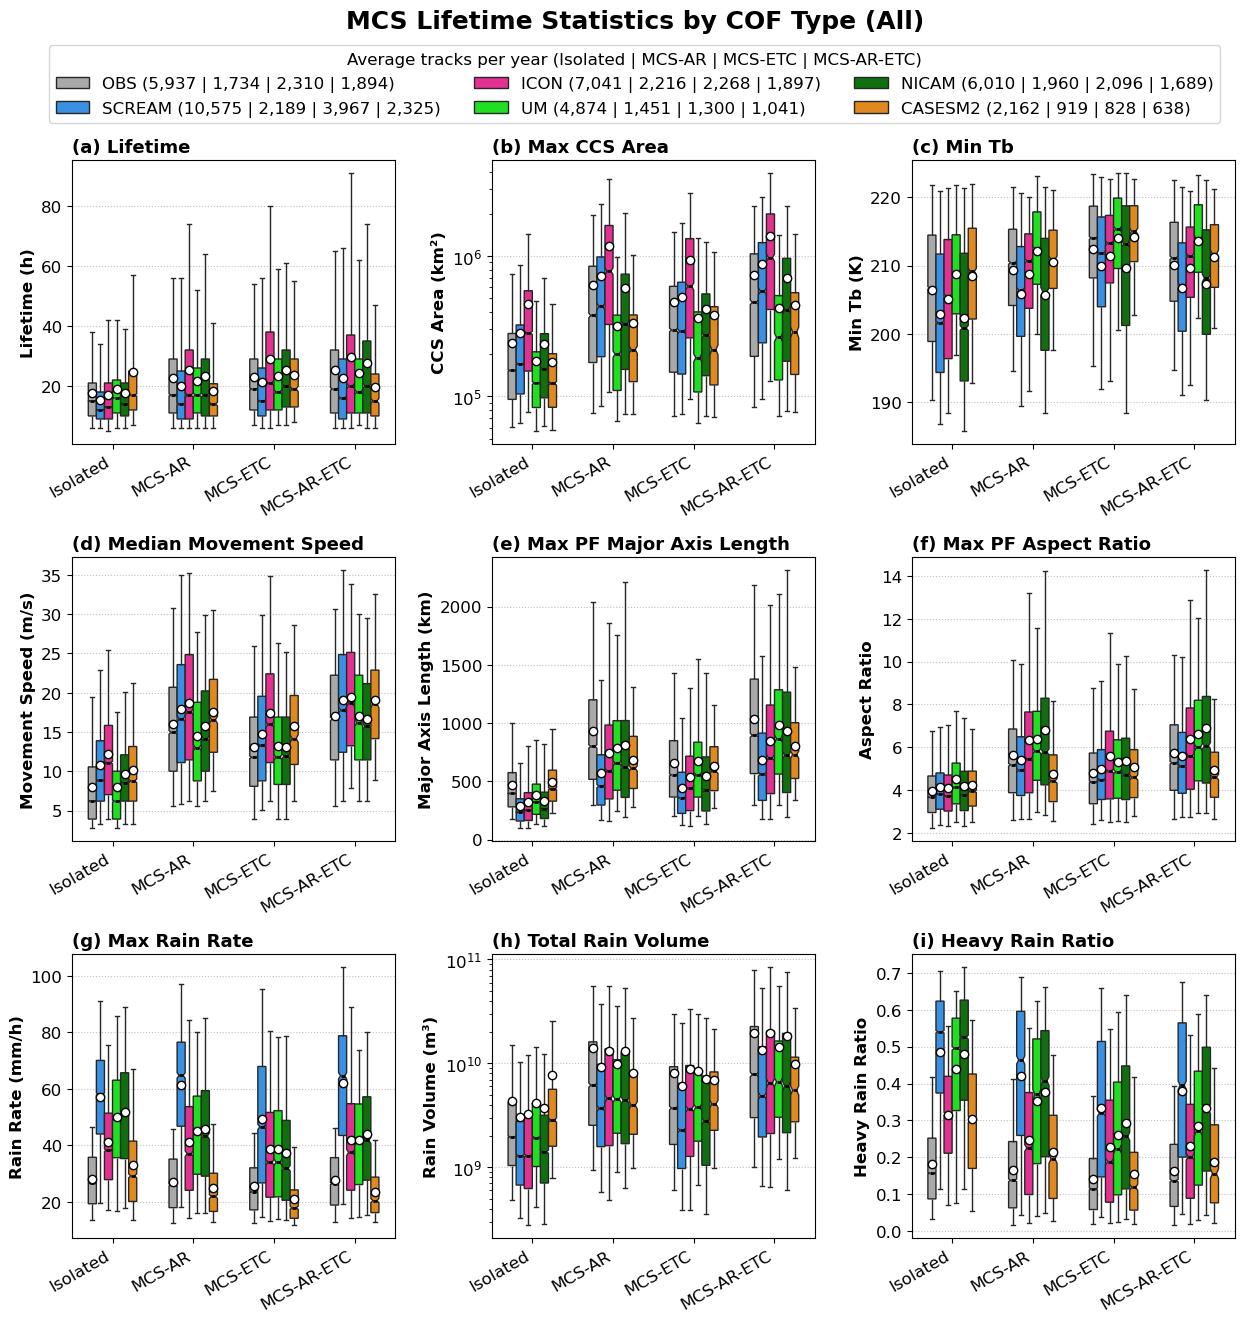

In [22]:
# Variable layout: 3 rows × 3 columns
lt_variables = [
    ['track_duration_h',  'ccs_area_all_lt_max',   'corecold_mintb_lt_min', ],
    ['movement_speed_lt_median',    'pf_majoraxis_lt_max',   'pf_aspectratio_lt_max', ],
    ['pf_maxrainrate_lt_max', 'total_rainvol_lt_sum',  'heavy_rain_ratio_lt_mean'],
]

panel_titles = [
    ['(a) Lifetime',      '(b) Max CCS Area',      '(c) Min Tb'],
    ['(d) Median Movement Speed',   '(e) Max PF Major Axis Length', '(f) Max PF Aspect Ratio'],
    ['(g) Max Rain Rate', '(h) Total Rain Volume',        '(i) Heavy Rain Ratio'],
]

lt_var_labels = {
    'track_duration_h':         'Lifetime (h)',
    'ccs_area_all_lt_max':      'CCS Area (km²)',
    'corecold_mintb_lt_min':    'Min Tb (K)',
    'pf_area_lt_max':           'PF Area (km²)',
    'pf_rainrate_lt_max':       'Rain Rate (mm/h)',
    'pf_majoraxis_lt_max':      'Major Axis Length (km)',
    'heavy_rain_ratio_lt_mean': 'Heavy Rain Ratio',
    'pf_aspectratio_lt_max':    'Aspect Ratio',
    'pf_maxrainrate_lt_max':    'Rain Rate (mm/h)',
    'total_rainvol_lt_sum':     'Rain Volume (m³)',
    'movement_speed_lt_median': 'Movement Speed (m/s)',
}

# yscale: set log scale for area and rain variables
lt_yscale = [
    ['linear', 'log',    'linear'],
    ['linear', 'linear', 'linear'],
    ['linear', 'log',    'linear'],
]

figname = f"{fig_dir}Boxplot_MCS_by4COFtypes_3x3.png"

fig = plot_boxplots_by_mcs_type(
    df_lt,
    lt_variables,
    lt_var_labels,
    figsize=(15, 14),
    title="MCS Lifetime Statistics by COF Type (All)",
    title_y=0.97,
    source_colors=source_colors,
    dataset_order=['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2'],
    box_width=0.6,
    xtick_rotation=30,
    notch=True,
    panel_titles=panel_titles,
    yscale=lt_yscale,
    fontsize=12,
    legend_ncol=3,
    legend_y=0.95,   # lower this (e.g. 0.99) to close gap to top panels
    hspace=0.4, wspace=0.3,
    n_years=n_years_by_dataset,
    figname=figname,
)
plt.show()


## Ocean vs. Land MCS Sub-populations

Split `df_lt` into **ocean** and **land** subsets based on the lifetime land-fraction:

| Subset | Criterion | Rationale |
|--------|-----------|-----------|
| Ocean | `pf_landfrac_lt_max < ocean_thresh` (default 0.05) | Track never had >5% of its PF over land |
| Land  | `pf_landfrac_lt_mean > land_thresh` (default 0.80) | Track spent >80% of its lifetime predominantly over land |

Adjust `ocean_thresh` and `land_thresh` in the cell below to change the definitions.


In [23]:
# ── Thresholds (adjust here) ──────────────────────────────────────────────────
ocean_thresh = 0.05   # pf_landfrac_lt_max < ocean_thresh  →  ocean MCS
land_thresh  = 0.80   # pf_landfrac_lt_mean > land_thresh  →  land  MCS

# ── Subsets ───────────────────────────────────────────────────────────────────
df_ocean = df_lt[df_lt['pf_landfrac_lt_max']  <  ocean_thresh].copy()
df_land  = df_lt[df_lt['pf_landfrac_lt_mean'] >  land_thresh ].copy()

print(f"ocean_thresh = {ocean_thresh}  →  {len(df_ocean):,} tracks "
      f"({100*len(df_ocean)/len(df_lt):.1f}% of total)")
print(f"land_thresh  = {land_thresh}  →  {len(df_land):,} tracks "
      f"({100*len(df_land)/len(df_lt):.1f}% of total)")

print("\nOcean tracks per dataset:")
print(df_ocean.groupby('dataset').size().to_frame('n_tracks').T.to_string())
print("\nLand tracks per dataset:")
print(df_land.groupby('dataset').size().to_frame('n_tracks').T.to_string())


ocean_thresh = 0.05  →  44,039 tracks (46.2% of total)
land_thresh  = 0.8  →  30,450 tracks (31.9% of total)

Ocean tracks per dataset:
dataset   CASESM2  ICON  NICAM    OBS  SCREAM    UM
n_tracks     2866  5023   5487  16342    9020  5301

Land tracks per dataset:
dataset   CASESM2  ICON  NICAM    OBS  SCREAM    UM
n_tracks      750  5221   3883  10719    7768  2109


Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs_202609/Boxplot_MCS_by4COFtypes_3x3_ocean.png


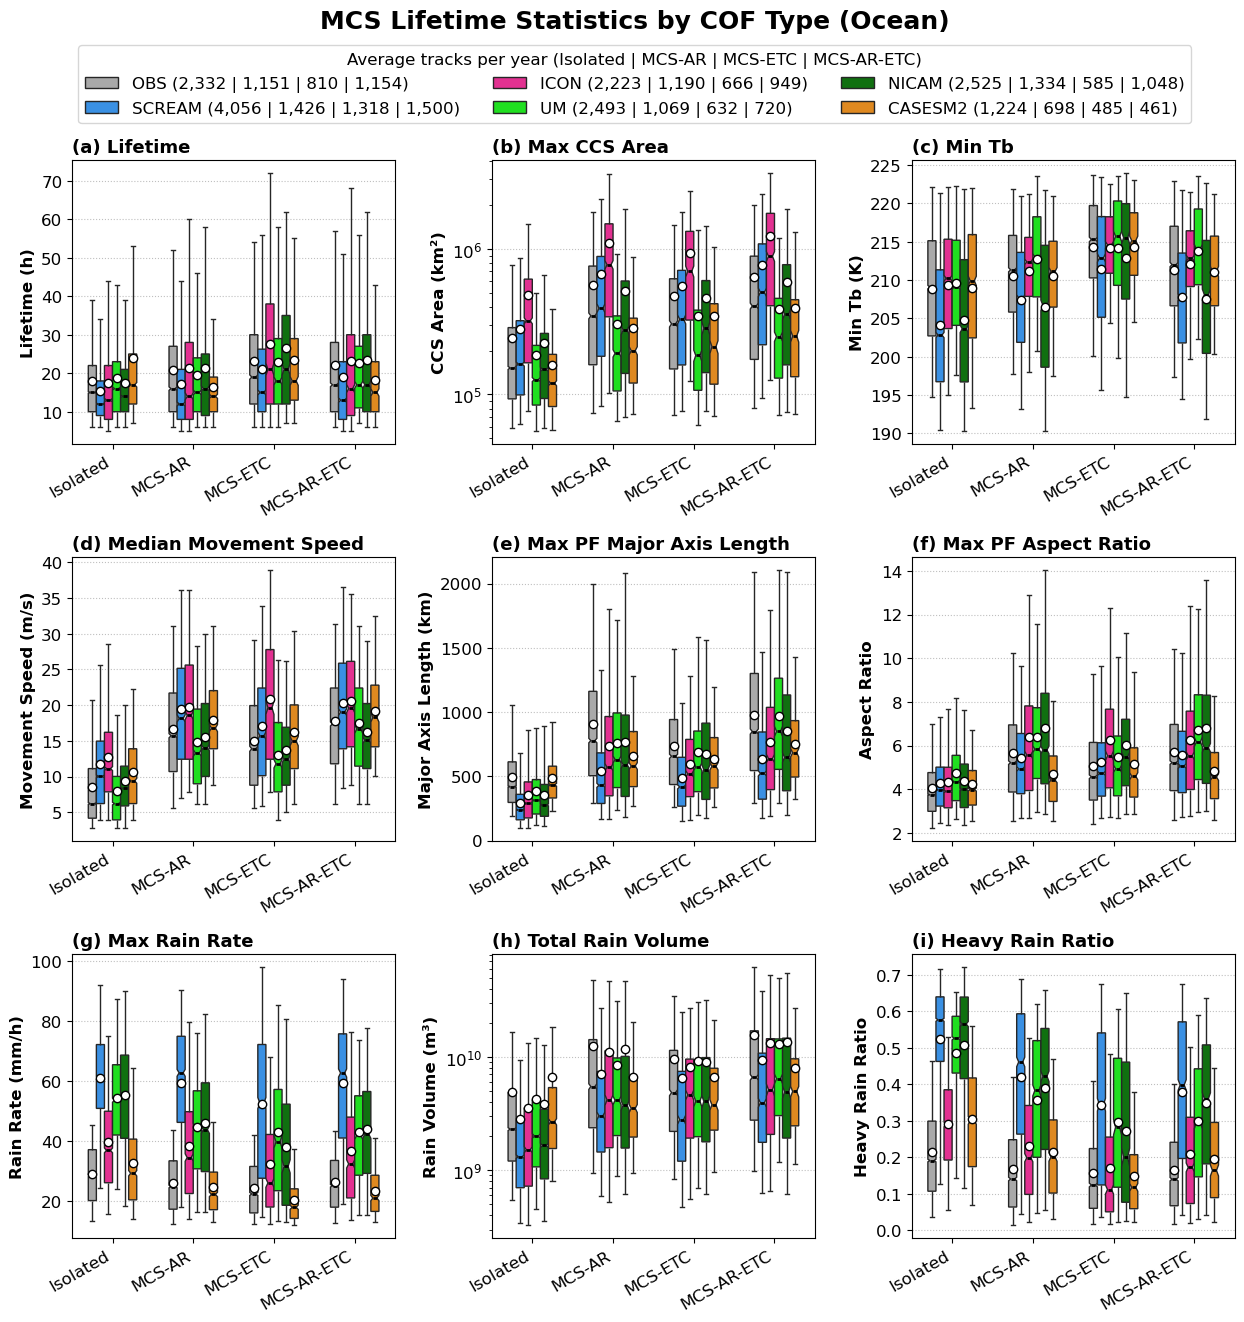

In [24]:
# ── Ocean MCS box plots ───────────────────────────────────────────────────────
figname_ocean = f"{fig_dir}Boxplot_MCS_by4COFtypes_3x3_ocean.png"

fig_ocean = plot_boxplots_by_mcs_type(
    df_ocean,
    lt_variables,
    lt_var_labels,
    figsize=(15, 14),
    title=f"MCS Lifetime Statistics by COF Type (Ocean)",
    title_y=0.97,
    source_colors=source_colors,
    dataset_order=['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2'],
    box_width=0.6,
    xtick_rotation=30,
    notch=True,
    panel_titles=panel_titles,
    yscale=lt_yscale,
    fontsize=12,
    legend_ncol=3,
    legend_y=0.95,
    hspace=0.4, wspace=0.3,
    n_years=n_years_by_dataset,
    figname=figname_ocean,
)
plt.show()


Figure saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs_202609/Boxplot_MCS_by4COFtypes_3x3_land.png


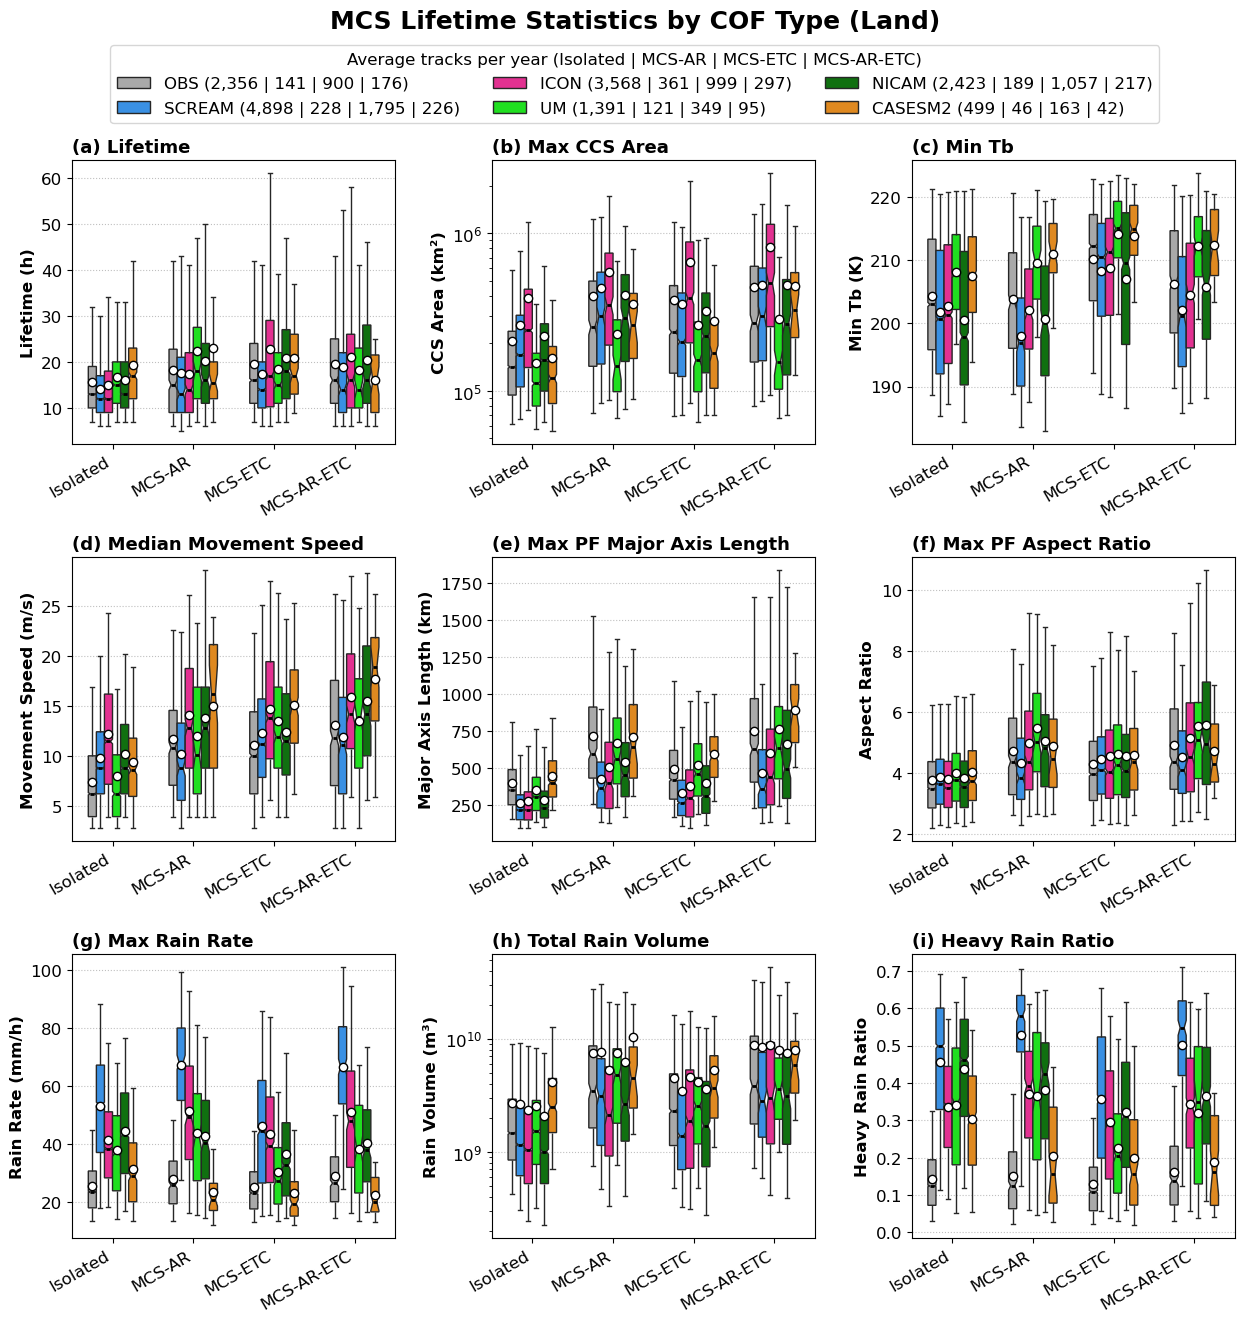

In [25]:
# ── Land MCS box plots ────────────────────────────────────────────────────────
figname_land = f"{fig_dir}Boxplot_MCS_by4COFtypes_3x3_land.png"

fig_land = plot_boxplots_by_mcs_type(
    df_land,
    lt_variables,
    lt_var_labels,
    figsize=(15, 14),
    title=f"MCS Lifetime Statistics by COF Type (Land)",
    title_y=0.97,
    source_colors=source_colors,
    dataset_order=['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2'],
    box_width=0.6,
    xtick_rotation=30,
    notch=True,
    panel_titles=panel_titles,
    yscale=lt_yscale,
    fontsize=12,
    legend_ncol=3,
    legend_y=0.95,
    hspace=0.4, wspace=0.3,
    n_years=n_years_by_dataset,
    figname=figname_land,
)
plt.show()


## MCS Type Difference Significance Test

For each dataset and each MCS lifetime statistics variable, compute the **mean % difference** of the three COF types (MCS-AR, MCS-ETC, MCS-AR-ETC) relative to the **Isolated** baseline, together with a **statistical significance test**.

### Method
| Aspect | Choice |
|---|---|
| Comparison | Each non-isolated COF type vs. Isolated |
| % difference | `(mean_type − mean_isolated) / abs(mean_isolated) × 100` |
| Significance test | **Mann-Whitney U** (two-sided, Wilcoxon rank-sum); chosen because variables such as `total_rainvol` and `pf_area` are heavily right-skewed and non-Gaussian |
| Significance threshold | α = 0.05 |

### Table layout
* **Rows** — MCS lifetime statistics variables  
* **Columns** — datasets (OBS, SCREAM, ICON, UM, NICAM, CASESM2)  
* **Cell content** — three lines, one per non-isolated COF type: `A: +49%`  
  A ✘ symbol is appended only when the result is **not** significant at α = 0.05 (e.g. `A: +49% ✘`); no symbol means significant.  
  Labels: `A` = MCS-AR, `E` = MCS-ETC, `E-A` = MCS-AR-ETC

Separate tables are produced for **land** and **ocean** sub-populations.


In [26]:
df_ds = df_land[df_land['dataset'] == 'OBS']
var = 'corecold_mintb_lt_min'
isolated = df_ds[df_ds['cof_type'] == 'Isolated'][var].dropna()
iso_mean = isolated.mean()
iso_mean

np.float32(204.29439)

In [27]:
# isolated.quantile(0.05), isolated.quantile(0.95)
isolated.quantile(0.05), isolated.quantile(0.95)

(np.float64(188.65887145996095), np.float64(221.30138549804687))

In [28]:
from scipy import stats
from IPython.display import display, HTML

# ── Settings ──────────────────────────────────────────────────────────────────
STAT_VARS = [
    'track_duration_h',
    'ccs_area_all_lt_max',
    'corecold_mintb_lt_min',
    'movement_speed_lt_median',
    'pf_majoraxis_lt_max',
    'pf_aspectratio_lt_max',
    'pf_maxrainrate_lt_max',
    'total_rainvol_lt_sum',
    'heavy_rain_ratio_lt_mean',
]

VAR_LABELS = {
    'track_duration_h':         'Lifetime',
    'ccs_area_all_lt_max':      'Max CCS Area',
    'corecold_mintb_lt_min':    'Min Tb',
    'movement_speed_lt_median': 'Median Move. Speed',
    'pf_majoraxis_lt_max':      'Max PF Major Axis',
    'pf_aspectratio_lt_max':    'Max PF Aspect Ratio',
    'pf_maxrainrate_lt_max':    'Max Rain Rate',
    'total_rainvol_lt_sum':     'Rain Volume (m³)',
    'heavy_rain_ratio_lt_mean': 'Heavy Rain Ratio',
}

DATASET_ORDER = ['OBS', 'SCREAM', 'ICON', 'UM', 'NICAM', 'CASESM2']

# (COF type column value, short label)
COF_COMPARE = [('MCS-AR', 'A'), ('MCS-ETC', 'E'), ('MCS-AR-ETC', 'E-A')]

ALPHA   = 0.05
NONSIG  = '✘'   # p >= alpha → not significant (only shown when insignificant)
MIN_N   = 5     # minimum sample size per group for the test to be valid


# ── Core computation ──────────────────────────────────────────────────────────
def compute_sig_table(df, stat_vars, var_labels, dataset_order, cof_compare, alpha, min_n):
    """
    For each (variable, dataset) pair compute the % mean difference and
    Mann-Whitney U significance for each non-isolated COF type vs. Isolated.

    Returns a dict[var][ds] = list of (pct_str, is_sig) per comparison.
    Mann-Whitney U is used because variables like total_rainvol and pf_area are
    heavily right-skewed (not suitable for parametric t-tests).
    """
    data = {}
    for var in stat_vars:
        data[var] = {}
        for ds in dataset_order:
            df_ds    = df[df['dataset'] == ds]
            isolated = df_ds[df_ds['cof_type'] == 'Isolated'][var].dropna()
            iso_mean = isolated.mean()

            comparisons = []
            for cot, label in cof_compare:
                other = df_ds[df_ds['cof_type'] == cot][var].dropna()

                # Guard: too few samples or degenerate baseline
                if len(isolated) < min_n or len(other) < min_n or iso_mean == 0 or np.isnan(iso_mean):
                    comparisons.append(('N/A', None))
                    continue

                pct_diff = (other.mean() - iso_mean) / abs(iso_mean) * 100
                pct_str  = f'{pct_diff:+.0f}%'   # rounded to integer

                # For Tb, compute the % difference relative to the 10-90 percentile range of the isolated group
                # This accounts for the fact that a 1 K difference is more meaningful if the typical range is 20 K than the mean value of 200 K.
                if 'mintb' in var:                    
                    iso_range = np.abs(isolated.quantile(0.90) - isolated.quantile(0.10))
                    pct_diff = (other.mean() - iso_mean) / iso_range * 100
                    pct_str  = f'{pct_diff:+.0f}%'  # rounded to integer

                # Mann-Whitney U test (two-sided, non-parametric)
                _, p = stats.mannwhitneyu(other, isolated, alternative='two-sided')
                is_sig = p < alpha

                comparisons.append((pct_str, is_sig))

            data[var][ds] = comparisons
    return data


# ── HTML table builder ────────────────────────────────────────────────────────
_CSS = """
<style>
.sigtab {
    border-collapse: collapse;
    font-size: 12px;
    font-family: Arial, sans-serif;
    margin-bottom: 20px;
}
.sigtab th {
    background-color: #4472C4;
    color: white;
    font-weight: bold;
    padding: 6px 10px;
    border: 1px solid #ccc;
    text-align: center;
}
.sigtab td {
    border: 1px solid #ccc;
    padding: 5px 8px;
    text-align: center;
    vertical-align: top;
    line-height: 1.6;
    background-color: #ffffff;
}
.sigtab td.varname {
    text-align: left;
    font-weight: bold;
    color: #000000;
    background-color: #ffffff;
    white-space: nowrap;
}
.pct-pos  { color: #c0392b; }   /* warm red for positive % */
.pct-neg  { color: #2471a3; }   /* blue for negative % */
.pct-na   { color: #999; }
.nonsig   { color: #000000; }
</style>
"""

def _pct_span(pct_str):
    """Wrap a % string in a coloured span."""
    if pct_str == 'N/A':
        return f'<span class="pct-na">–</span>'
    cls = 'pct-pos' if pct_str.startswith('+') else 'pct-neg'
    return f'<span class="{cls}">{pct_str}</span>'


def build_html_table(data, stat_vars, var_labels, dataset_order, cof_compare, title):
    """Render the pre-computed data dict as an HTML table."""
    html = _CSS + f'<h3 style="font-family:Arial;color:#000">{title}</h3>\n'
    html += '<table class="sigtab"><thead><tr>'
    html += '<th>Variable</th>'
    for ds in dataset_order:
        html += f'<th>{ds}</th>'
    html += '</tr></thead><tbody>\n'

    for var in stat_vars:
        html += '<tr>'
        html += f'<td class="varname">{var_labels[var]}</td>'

        for ds in dataset_order:
            comparisons = data[var][ds]
            lines = []

            for i, (cot, label) in enumerate(cof_compare):
                pct_str, is_sig = comparisons[i]
                # Significant: just "A: +49%"
                # Insignificant: "A: +49% ✘" (cross appended)
                lbl_html = f'<span style="color:#000">{label}:</span>'
                if is_sig is None:
                    line = f'{lbl_html} {_pct_span(pct_str)}'
                elif is_sig:
                    line = f'{lbl_html} {_pct_span(pct_str)}'
                else:
                    line = (f'{lbl_html} {_pct_span(pct_str)} '
                            f'<span class="nonsig">{NONSIG}</span>')
                lines.append(line)

            html += f'<td>{"<br>".join(lines)}</td>'

        html += '</tr>\n'

    html += '</tbody></table>'
    return html


# ── Run for land and ocean ────────────────────────────────────────────────────
html_tables = {}
for subset_name, df_sub in [('Land', df_land), ('Ocean', df_ocean)]:
    data = compute_sig_table(
        df_sub, STAT_VARS, VAR_LABELS, DATASET_ORDER, COF_COMPARE, ALPHA, MIN_N
    )
    title_str = (
        f'{subset_name} MCS — Mean % Difference vs Isolated '
        f'(Mann-Whitney U, α={ALPHA}; ✘ = not significant at p < {ALPHA})'
    )
    html_tables[subset_name] = build_html_table(
        data, STAT_VARS, VAR_LABELS, DATASET_ORDER, COF_COMPARE, title=title_str,
    )
    display(HTML(html_tables[subset_name]))


Variable,OBS,SCREAM,ICON,UM,NICAM,CASESM2
Lifetime,A: +17%E: +26%E-A: +25%,A: +23%E: +22%E-A: +33%,A: +16%E: +52%E-A: +42%,A: +34%E: +11% ✘E-A: +10% ✘,A: +26%E: +30%E-A: +27%,A: +19% ✘E: +8% ✘E-A: -17% ✘
Max CCS Area,A: +94%E: +82%E-A: +120%,A: +73%E: +36%E-A: +80%,A: +47%E: +71%E-A: +111%,A: +54%E: +75%E-A: +91%,A: +83%E: +44%E-A: +112%,A: +120%E: +73%E-A: +190%
Min Tb,A: -2% ✘E: +22%E-A: +7%,A: -12%E: +21%E-A: +1% ✘,A: -2% ✘E: +21%E-A: +6%,A: +7%E: +29%E-A: +21%,A: +1% ✘E: +20%E-A: +16%,A: +16%E: +29%E-A: +22%
Median Move. Speed,A: +57%E: +49%E-A: +76%,A: +4% ✘E: +26%E-A: +22%,A: +15%E: +20%E-A: +30%,A: +49%E: +69%E-A: +69%,A: +35%E: +21%E-A: +52%,A: +59%E: +60%E-A: +87%
Max PF Major Axis,A: +79%E: +24%E-A: +87%,A: +62%E: +26%E-A: +78%,A: +84%E: +37%E-A: +118%,A: +88%E: +47%E-A: +116%,A: +90%E: +40%E-A: +134%,A: +58%E: +33%E-A: +98%
Max PF Aspect Ratio,A: +25%E: +14%E-A: +30%,A: +12%E: +15%E-A: +16%,A: +32%E: +20%E-A: +36%,A: +37%E: +16%E-A: +38%,A: +32%E: +18%E-A: +45%,A: +20%E: +13%E-A: +17%
Max Rain Rate,A: +9%E: -1% ✘E-A: +13%,A: +27%E: -13%E-A: +25%,A: +24%E: +5% ✘E-A: +24%,A: +16%E: -20%E-A: +1% ✘,A: -4% ✘E: -18%E-A: -9%,A: -26%E: -27%E-A: -29%
Rain Volume (m³),A: +179%E: +65%E-A: +228%,A: +191%E: +30%E-A: +218%,A: +126%E: +98%E-A: +275%,A: +199%E: +63%E-A: +217%,A: +198%E: +75%E-A: +262%,A: +146%E: +27%E-A: +91%
Heavy Rain Ratio,A: +6% ✘E: -10%E-A: +13%,A: +15%E: -22%E-A: +10%,A: +10%E: -12%E-A: +2% ✘,A: +7% ✘E: -33%E-A: -6% ✘,A: -12%E: -26%E-A: -16%,A: -32%E: -35%E-A: -38%


Variable,OBS,SCREAM,ICON,UM,NICAM,CASESM2
Lifetime,A: +16%E: +29%E-A: +23%,A: +12% ✘E: +37%E-A: +23%,A: +23%E: +58%E-A: +34%,A: +4% ✘E: +23%E-A: +21%,A: +21%E: +51%E-A: +34%,A: -31%E: -2%E-A: -23%
Max CCS Area,A: +131%E: +93%E-A: +162%,A: +137%E: +98%E-A: +176%,A: +127%E: +93%E-A: +154%,A: +63%E: +87%E-A: +106%,A: +126%E: +103%E-A: +161%,A: +81%E: +115%E-A: +144%
Min Tb,A: +8%E: +25%E-A: +11%,A: +13%E: +29%E-A: +14%,A: +8%E: +23%E-A: +13%,A: +15%E: +23%E-A: +21%,A: +6%E: +30%E-A: +11%,A: +7%E: +23%E-A: +9%
Median Move. Speed,A: +96%E: +76%E-A: +109%,A: +65%E: +45%E-A: +73%,A: +54%E: +63%E-A: +61%,A: +86%E: +63%E-A: +119%,A: +66%E: +46%E-A: +74%,A: +70%E: +53%E-A: +81%
Max PF Major Axis,A: +84%E: +50%E-A: +98%,A: +86%E: +67%E-A: +116%,A: +107%E: +68%E-A: +117%,A: +97%E: +79%E-A: +152%,A: +116%E: +89%E-A: +140%,A: +35%E: +30%E-A: +55%
Max PF Aspect Ratio,A: +39%E: +24%E-A: +40%,A: +26%E: +21%E-A: +29%,A: +48%E: +45%E-A: +45%,A: +36%E: +15%E-A: +42%,A: +55%E: +37%E-A: +55%,A: +11%E: +21%E-A: +14%
Max Rain Rate,A: -10%E: -15%E-A: -9%,A: -3% ✘E: -14%E-A: -3% ✘,A: -4%E: -19%E-A: -8%,A: -18%E: -21%E-A: -21%,A: -17%E: -31%E-A: -20%,A: -24%E: -38%E-A: -29%
Rain Volume (m³),A: +155%E: +98%E-A: +222%,A: +151%E: +132%E-A: +230%,A: +217%E: +134%E-A: +278%,A: +100%E: +117%E-A: +209%,A: +202%E: +131%E-A: +247%,A: -0%E: +1%E-A: +22%
Heavy Rain Ratio,A: -21%E: -27%E-A: -22%,A: -20%E: -35%E-A: -28%,A: -21%E: -42%E-A: -29%,A: -27%E: -39%E-A: -38%,A: -23%E: -46%E-A: -31%,A: -29%E: -51%E-A: -36%


In [29]:
# ── Save tables as standalone HTML files (for use in Microsoft Word) ─────────
# Word can open .html files directly (File → Open) and preserves table formatting.
# Alternatively: open the .html in a browser, select the table, and paste into Word.

save_dir = fig_dir   # reuse the figure output directory

_HTML_WRAP = """\
<!DOCTYPE html>
<html><head>
<meta charset="utf-8">
<title>{title}</title>
</head><body>
{body}
</body></html>
"""

for subset_name, html_body in html_tables.items():
    out_path = os.path.join(save_dir, f'Table_MCS_sig_{subset_name.lower()}.html')
    with open(out_path, 'w', encoding='utf-8') as fh:
        fh.write(_HTML_WRAP.format(
            title=f'MCS Significance Table — {subset_name}',
            body=html_body,
        ))
    print(f"Saved: {out_path}")

print("\nTo use in Word:")
print("  Option 1 — open the .html file directly in Word (File → Open → select .html).")
print("  Option 2 — open in a browser, select the full table, copy (Ctrl+C), paste into Word.")


Saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs_202609/Table_MCS_sig_land.html
Saved: /global/cfs/cdirs/m1867/zfeng/hk25/figures_mcs_202609/Table_MCS_sig_ocean.html

To use in Word:
  Option 1 — open the .html file directly in Word (File → Open → select .html).
  Option 2 — open in a browser, select the full table, copy (Ctrl+C), paste into Word.
